In [74]:
import torch
import torch.nn as nn
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [75]:
train_hazy = "D:/RESIDE-6K/train/hazy"
train_gt   = "D:/RESIDE-6K/train/GT"

test_hazy  = "D:/RESIDE-6K/test/hazy"
test_gt    = "D:/RESIDE-6K/test/GT"

In [76]:
class DehazeDataset(Dataset):
    def __init__(self, hazy_path, gt_path):
        self.hazy_images = sorted(os.listdir(hazy_path))
        self.gt_images   = sorted(os.listdir(gt_path))
        self.hazy_path = hazy_path
        self.gt_path   = gt_path

    def __len__(self):
        return len(self.hazy_images)

    def __getitem__(self, idx):
        hazy = cv2.imread(os.path.join(self.hazy_path, self.hazy_images[idx]))
        gt   = cv2.imread(os.path.join(self.gt_path, self.gt_images[idx]))

        hazy = cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB)
        gt   = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

        hazy = cv2.resize(hazy, (256,256))
        gt   = cv2.resize(gt, (256,256))

        hazy = torch.tensor(hazy).permute(2,0,1).float()/255.0
        gt   = torch.tensor(gt).permute(2,0,1).float()/255.0

        return hazy, gt

In [77]:
dataset = DehazeDataset(train_hazy, train_gt)

loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset Loaded ✅")

Dataset Loaded ✅


In [78]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.ReLU(),
            nn.Conv2d(32,3,3,padding=1)
        )
    def forward(self,x):
        return x + self.net(x)

In [79]:
class ResCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,3,3,padding=1)

    def forward(self,x):
        return x + self.conv2(torch.relu(self.conv1(x)))

In [80]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,3,padding=1)
        self.conv2 = nn.Conv2d(64,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,3,3,padding=1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        return x + self.conv3(x2)

In [81]:
class AODNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,3,1)
        self.conv2 = nn.Conv2d(3,3,3,padding=1)
        self.conv3 = nn.Conv2d(3,3,5,padding=2)

    def forward(self,x):
        k = self.conv1(x) + self.conv2(x) + self.conv3(x)
        return k*x - k + 1

In [82]:
class GAT_Block(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, in_channels, 1)
        self.conv2 = nn.Conv2d(in_channels, in_channels, 1)

    def forward(self, x):
        attn = torch.sigmoid(self.conv1(x))
        out = self.conv2(x * attn)

        return out + x

In [83]:
class GAT_Dehaze(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU()
        )

        self.gat = GAT_Block(64)

        self.decoder = nn.Sequential(
            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        f = self.encoder(x)
        f = self.gat(f)
        out = self.decoder(f)

        return out

In [84]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [85]:
class CNN_GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNN()
        self.gnn = GAT_Dehaze()

    def forward(self, x):
        x = self.cnn(x)
        x = self.gnn(x)
        return x

In [86]:
import torch
import torch.nn as nn

class CNN_GAT_Fusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNN()
        self.gat = GAT_Dehaze()

    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.gat(x)

        return f1 + f2  

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_GAT_Fusion_Strong(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = UNet()             
        self.gat = GAT_Dehaze()

        self.fuse = nn.Conv2d(6, 3, 1) 

    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.gat(x)

        fused = torch.cat([f1, f2], dim=1)
        return self.fuse(fused)

class Final_Model_Strong(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = CNN_GAT_Fusion_Strong()

    def forward(self, x):

    
        out1 = self.model(x)

        x_small = F.interpolate(x, scale_factor=0.5)
        out2 = self.model(x_small)
        out2 = F.interpolate(out2, size=x.shape[2:])

        return torch.clamp((out1 + out2)/2, 0, 1)

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        return x + self.conv2(F.relu(self.conv1(x)))


# -------- SIMPLE UNET BACKBONE --------
class UNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, 3, padding=1)

        self.res = ResBlock(128)

        self.dec1 = nn.Conv2d(128, 64, 3, padding=1)
        self.out = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, x):
        x1 = F.relu(self.enc1(x))
        x2 = F.relu(self.enc2(F.max_pool2d(x1, 2)))

        x2 = self.res(x2)

        x3 = F.interpolate(x2, scale_factor=2)
        x3 = F.relu(self.dec1(x3 + x1))

        return torch.sigmoid(self.out(x3))


class CNN_GAT_Fusion_Strong(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = UNetBackbone()
        self.gat = GAT_Dehaze()  

        self.fuse = nn.Conv2d(6, 3, 1) 

    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.gat(x)

        fused = torch.cat([f1, f2], dim=1)
        return self.fuse(fused)

class Final_Model_Strong(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = CNN_GAT_Fusion_Strong()

    def forward(self, x):

        out1 = self.model(x)

        x_small = F.interpolate(x, scale_factor=0.5)
        out2 = self.model(x_small)
        out2 = F.interpolate(out2, size=x.shape[2:])

        out = (out1 + out2) / 2

        return torch.clamp(out, 0, 1)

In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(ch)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return x + out

class SEBlock(nn.Module):
    def __init__(self, ch, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(ch, ch // reduction)
        self.fc2 = nn.Linear(ch // reduction, ch)

    def forward(self, x):
        b, c, h, w = x.size()
        y = x.view(b, c, -1).mean(dim=2)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))
        y = y.view(b, c, 1, 1)
        return x * y


class UNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.res = ResBlock(128)

        self.dec1 = nn.Sequential(
            nn.Conv2d(192, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.attn = SEBlock(64)
        self.out = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(F.max_pool2d(x1, 2))

        x2 = self.res(x2)

        x3 = F.interpolate(x2, scale_factor=2, mode='bilinear', align_corners=False)

        x3 = torch.cat([x3, x1], dim=1)

        x3 = self.dec1(x3)
        x3 = self.attn(x3)

        return torch.sigmoid(self.out(x3))

class CNN_GAT_Fusion_Strong(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = UNetBackbone()
        self.gat = GAT_Dehaze()

        self.fuse = nn.Sequential(
            nn.Conv2d(6, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 1)
        )

    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.gat(x)

        fused = torch.cat([f1, f2], dim=1)
        return torch.clamp(self.fuse(fused), 0, 1)

class Final_Model_Strong(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = CNN_GAT_Fusion_Strong()

    def forward(self, x):

        out1 = self.model(x)

        x_small = F.interpolate(x, scale_factor=0.5, mode='bilinear', align_corners=False)
        out2 = self.model(x_small)
        out2 = F.interpolate(out2, size=x.shape[2:], mode='bilinear', align_corners=False)

        out = 0.6 * out1 + 0.4 * out2

        return torch.clamp(out, 0, 1)

In [90]:
model_dict = {
    "CNN": CNN().to(device),
    "ResCNN": ResCNN().to(device),
    "UNet": UNet().to(device),
    "AOD-Net": AODNet().to(device),
    "GAT": GAT_Dehaze().to(device),
    "CNN-GNN": CNN_GNN().to(device),
    "CNN+GAT": CNN_GAT_Fusion_Strong().to(device),
    "Proposed": Final_Model_Strong().to(device)
}

In [91]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    return 100 if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))


def compute_ssim(img1, img2):
    img1 = torch.tensor(img1).permute(2,0,1).unsqueeze(0).float()/255.0
    img2 = torch.tensor(img2).permute(2,0,1).unsqueeze(0).float()/255.0
    return ssim(img1, img2, data_range=1.0).item()

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models as tv_models

class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features[:16]
        self.vgg = vgg.eval()
        for p in self.vgg.parameters():
            p.requires_grad = False

    def forward(self, x, y):
        return F.l1_loss(self.vgg(x), self.vgg(y))


perc_loss_fn = PerceptualLoss().to(device)
l1_loss_fn = nn.L1Loss()

results = {}

for name, model in model_dict.items():

    print("\n====================")
    print("Training:", name)

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=30, gamma=0.5
    )

    epochs = 100

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        print(f"{name} Epoch {epoch+1}")

        for hazy, gt in loader:

            hazy, gt = hazy.to(device), gt.to(device)

            output = model(hazy)

            if isinstance(output, tuple):
                pred, t, A = output
            else:
                pred = output
                t, A = None, None

            pred = torch.clamp(pred, 0, 1)

            loss_l1 = l1_loss_fn(pred, gt)
            loss_l2 = F.mse_loss(pred, gt)

            ssim_loss = ssim(pred, gt, data_range=1.0)
            loss_perc = perc_loss_fn(pred, gt)

            loss = (
                loss_l1
                + 0.3 * (1 - ssim_loss)
                + 0.2 * loss_l2
                + 0.01 * loss_perc
            )

            if t is not None and A is not None:
                loss_t = torch.mean(torch.abs(t))
                loss_A = torch.mean(torch.abs(A))
                loss += 0.03 * loss_t + 0.01 * loss_A

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        print(f"Loss: {total_loss/len(loader):.4f}")

    torch.save(model.state_dict(), f"{name}.pth")

    model.eval()

    psnr_list = []
    ssim_list = []

    hazy_files = sorted(os.listdir(test_hazy))
    gt_files   = sorted(os.listdir(test_gt))

    n = min(len(hazy_files), len(gt_files))

    for i in range(n):

        hazy = cv2.imread(os.path.join(test_hazy, hazy_files[i]))
        gt   = cv2.imread(os.path.join(test_gt, gt_files[i]))

        if hazy is None or gt is None:
            continue

        hazy = cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB)
        gt   = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

        hazy = cv2.resize(hazy, (256,256))
        gt   = cv2.resize(gt, (256,256))

        inp = torch.from_numpy(hazy).permute(2,0,1).unsqueeze(0).float().to(device)/255.0

        with torch.no_grad():
            output = model(inp)

        if isinstance(output, tuple):
            output = output[0]

        output = torch.clamp(output, 0, 1)

        out = output.squeeze().permute(1,2,0).cpu().numpy()
        out = (out * 255).astype(np.uint8)

        psnr_list.append(psnr(gt, out))
        ssim_list.append(compute_ssim(gt, out))

    avg_psnr = np.mean(psnr_list)
    avg_ssim = np.mean(ssim_list)

    print(f"{name} → PSNR: {avg_psnr:.2f}, SSIM: {avg_ssim:.4f}")

    results[name] = [avg_psnr, avg_ssim]

print("\n==================== FINAL RESULTS ====================")

for name, (p, s) in results.items():
    print(f"{name}: PSNR={p:.2f}, SSIM={s:.4f}")


Training: CNN
CNN Epoch 1
Loss: 0.1715
CNN Epoch 2
Loss: 0.1519
CNN Epoch 3
Loss: 0.1492
CNN Epoch 4
Loss: 0.1480
CNN Epoch 5
Loss: 0.1474
CNN Epoch 6
Loss: 0.1469
CNN Epoch 7
Loss: 0.1463
CNN Epoch 8
Loss: 0.1458
CNN Epoch 9
Loss: 0.1456
CNN Epoch 10
Loss: 0.1450
CNN Epoch 11
Loss: 0.1447
CNN Epoch 12
Loss: 0.1446
CNN Epoch 13
Loss: 0.1443
CNN Epoch 14
Loss: 0.1445
CNN Epoch 15
Loss: 0.1441
CNN Epoch 16
Loss: 0.1436
CNN Epoch 17
Loss: 0.1436
CNN Epoch 18
Loss: 0.1437
CNN Epoch 19
Loss: 0.1434
CNN Epoch 20
Loss: 0.1431
CNN Epoch 21
Loss: 0.1431
CNN Epoch 22
Loss: 0.1429
CNN Epoch 23
Loss: 0.1428
CNN Epoch 24
Loss: 0.1427
CNN Epoch 25
Loss: 0.1424
CNN Epoch 26
Loss: 0.1426
CNN Epoch 27
Loss: 0.1425
CNN Epoch 28
Loss: 0.1421
CNN Epoch 29
Loss: 0.1422
CNN Epoch 30
Loss: 0.1420
CNN Epoch 31
Loss: 0.1410
CNN Epoch 32
Loss: 0.1410
CNN Epoch 33
Loss: 0.1409
CNN Epoch 34
Loss: 0.1406
CNN Epoch 35
Loss: 0.1407
CNN Epoch 36
Loss: 0.1407
CNN Epoch 37
Loss: 0.1406
CNN Epoch 38
Loss: 0.1404
CNN Ep

RuntimeError: The size of tensor a (128) must match the size of tensor b (64) at non-singleton dimension 1

In [18]:
import pandas as pd

df = pd.DataFrame(results, index=["PSNR", "SSIM"]).T
df = df.reset_index()
df.columns = ["Model", "PSNR", "SSIM"]

df["PSNR"] = df["PSNR"].round(2)
df["SSIM"] = df["SSIM"].round(4)

df = df.sort_values(by="PSNR", ascending=False)

print("\nFinal Table:")
print(df.to_string(index=False))


Final Table:
   Model  PSNR   SSIM
 CNN-GNN 29.10 0.8836
Proposed 29.09 0.8833
     GAT 29.05 0.8773
     CNN 29.02 0.8801
    UNet 29.01 0.8768
  ResCNN 28.81 0.8736
 AOD-Net 28.63 0.8634


In [19]:
os.makedirs("results", exist_ok=True)
df.to_csv("results/metrics.csv", index=False)

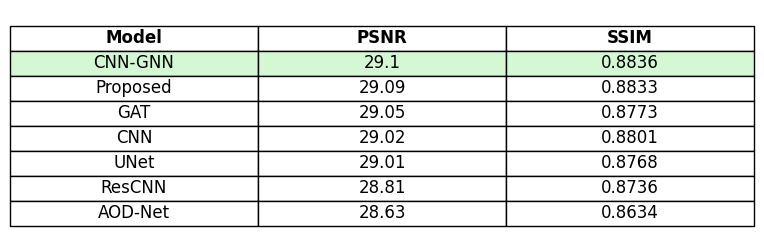

In [20]:
plt.figure(figsize=(8,3))
table = plt.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

for j in range(len(df.columns)):
    table[1, j].set_facecolor("#d4f7d4")

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.axis('off')

plt.savefig("results/results_table.png", bbox_inches='tight', dpi=300)
plt.show()

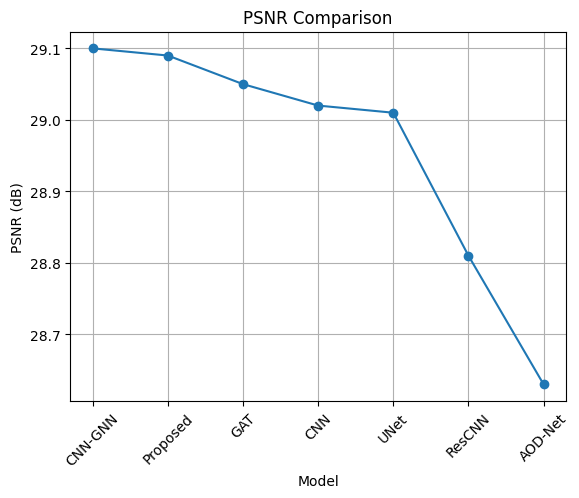

In [21]:
plt.figure()
plt.plot(df["Model"], df["PSNR"], marker='o')
plt.title("PSNR Comparison")
plt.xlabel("Model")
plt.ylabel("PSNR (dB)")
plt.xticks(rotation=45)
plt.grid()

plt.savefig("results/psnr_plot.png", dpi=300, bbox_inches='tight')
plt.show()

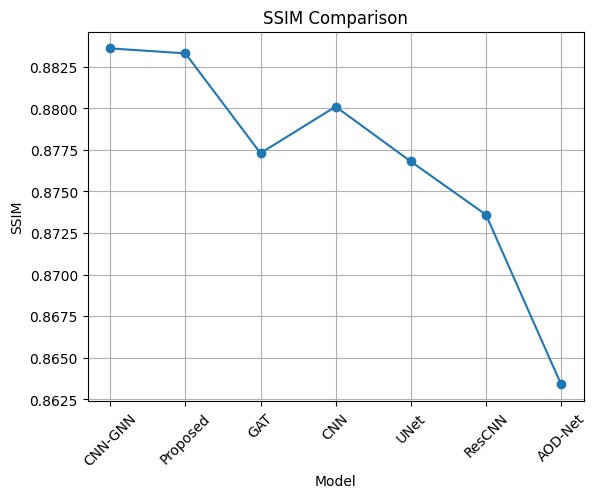

In [22]:
plt.figure()
plt.plot(df["Model"], df["SSIM"], marker='o')
plt.title("SSIM Comparison")
plt.xlabel("Model")
plt.ylabel("SSIM")
plt.xticks(rotation=45)
plt.grid()

plt.savefig("results/ssim_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [67]:
models = ["CNN", "ResCNN", "UNet", "AOD-Net", "GAT", "CNN-GNN", "Proposed"]

psnr = [29.02, 28.81, 29.01, 28.63, 29.05, 29.10, 29.09]
ssim = [0.8801, 0.8736, 0.8768, 0.8634, 0.8773, 0.8836, 0.8833]

In [23]:
import os

save_path = "./results"   
os.makedirs(save_path, exist_ok=True)

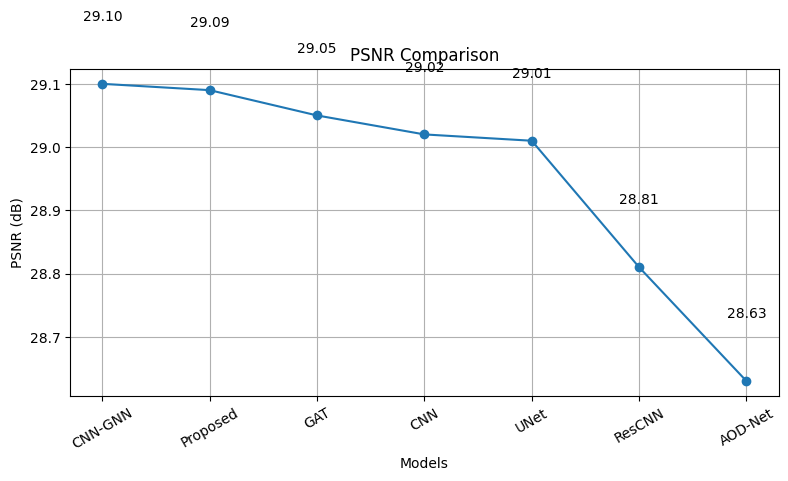

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_sorted = df.sort_values(by="PSNR", ascending=False)

plt.plot(df_sorted["Model"], df_sorted["PSNR"], marker='o')

for i, val in enumerate(df_sorted["PSNR"]):
    plt.text(i, val + 0.1, f"{val:.2f}", ha='center')

plt.xlabel("Models")
plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison")
plt.grid()

plt.xticks(rotation=30) 

plt.tight_layout()

plt.savefig(os.path.join(save_path, "psnr_graph.png"), dpi=300, bbox_inches='tight')
plt.show()

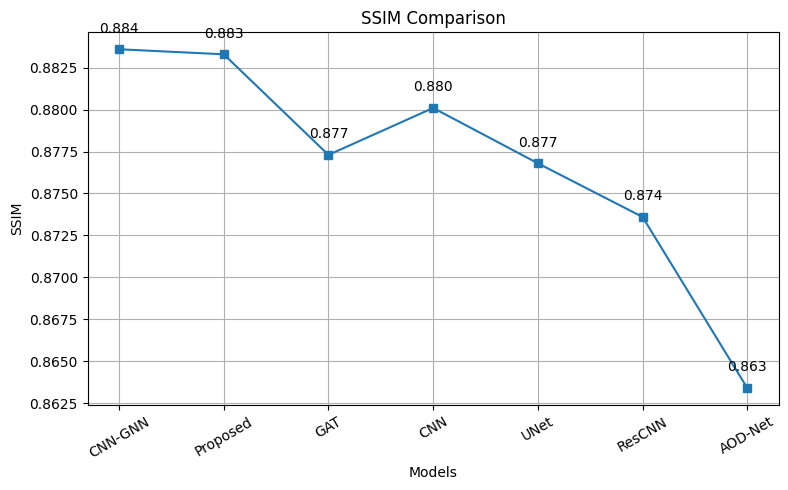

In [25]:
plt.figure(figsize=(8,5))

plt.plot(df_sorted["Model"], df_sorted["SSIM"], marker='s')

for i, val in enumerate(df_sorted["SSIM"]):
    plt.text(i, val + 0.001, f"{val:.3f}", ha='center')

plt.xlabel("Models")
plt.ylabel("SSIM")
plt.title("SSIM Comparison")
plt.grid()

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(os.path.join(save_path, "ssim_graph.png"), dpi=300, bbox_inches='tight')
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def tensor_to_img(tensor):
    if tensor.dim() == 4:
        tensor = tensor[0]

    tensor = tensor.detach().cpu()

    min_val = tensor.min()
    max_val = tensor.max()

    if (max_val - min_val) > 1e-8:
        tensor = (tensor - min_val) / (max_val - min_val)

    img = tensor.permute(1, 2, 0).numpy()
    return img

hazy_img = tensor_to_img(hazy)

print("Available models:", outputs.keys())

model_name = "Proposed"

if model_name not in outputs:
    print("⚠️ Proposed not found! Using fallback.")
    model_name = list(outputs.keys())[0]

out = outputs[model_name]


if isinstance(out, tuple):
    out = out[0]

dehazed_img = tensor_to_img(out)

def slider_view(alpha=0.5):
    blended = (1 - alpha) * hazy_img + alpha * dehazed_img

    plt.figure(figsize=(6, 6))
    plt.imshow(np.clip(blended, 0, 1))
    plt.title(f"{model_name} | Blend: {alpha:.2f}")
    plt.axis('off')
    plt.show()


interact(slider_view, alpha=(0.0, 1.0, 0.01))

Available models: dict_keys(['CNN', 'ResCNN', 'UNet', 'AOD-Net', 'GAT', 'CNN-GNN', 'Proposed'])


interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.01), Output()), _dom_classes…

<function __main__.slider_view(alpha=0.5)>

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def tensor_to_img(tensor):
    if tensor.dim() == 4:
        tensor = tensor[0]

    tensor = tensor.detach().cpu()

    min_val = tensor.min()
    max_val = tensor.max()

    if (max_val - min_val) > 1e-8:
        tensor = (tensor - min_val) / (max_val - min_val)

    return tensor.permute(1, 2, 0).numpy()

hazy_img = tensor_to_img(hazy)
if len(outputs) == 0:
    raise ValueError("❌ outputs is empty! Run model inference first.")

model_name = "Proposed" if "Proposed" in outputs else list(outputs.keys())[0]

out = outputs[model_name]

if isinstance(out, tuple):
    out = out[0]

dehazed_img = tensor_to_img(out)


def slider_view(alpha=0.5):
    blended = (1 - alpha) * hazy_img + alpha * dehazed_img

    plt.figure(figsize=(6,6))
    plt.imshow(np.clip(blended, 0, 1))
    plt.title(f"{model_name} | Blend: {alpha:.2f}")
    plt.axis('off')
    plt.show()


interact(slider_view, alpha=(0.0, 1.0, 0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.01), Output()), _dom_classes…

<function __main__.slider_view(alpha=0.5)>

In [34]:
def compare_model(model_name, alpha=0.5):
    out = outputs[model_name]

    if isinstance(out, tuple):
        out = out[0]

    dehazed = tensor_to_img(out)
    blended = (1 - alpha) * hazy_img + alpha * dehazed

    plt.figure(figsize=(6,6))
    plt.imshow(np.clip(blended, 0, 1))
    plt.title(f"{model_name} | Blend: {alpha:.2f}")
    plt.axis('off')
    plt.show()


interact(compare_model, 
         model_name=list(outputs.keys()), 
         alpha=(0.0, 1.0, 0.01))

interactive(children=(Dropdown(description='model_name', options=('CNN', 'ResCNN', 'UNet', 'AOD-Net', 'GAT', '…

<function __main__.compare_model(model_name, alpha=0.5)>

In [35]:
print(outputs.keys())

dict_keys(['CNN', 'ResCNN', 'UNet', 'AOD-Net', 'GAT', 'CNN-GNN', 'Proposed'])


In [36]:
import os

save_path = r"D:\Sunder"

os.makedirs(save_path, exist_ok=True)

In [37]:
import torch
import numpy as np

def tensor_to_img(tensor):

    if isinstance(tensor, np.ndarray):
        tensor = torch.from_numpy(tensor)

    if tensor.dim() == 4:
        tensor = tensor[0]

    tensor = tensor.detach().cpu().float()

    if tensor.max() > 1:
        tensor = tensor / 255.0

    tensor = torch.clamp(tensor, 0, 1)

    if tensor.dim() == 2:
        tensor = tensor.unsqueeze(0)   # (H,W) → (1,H,W)

    if tensor.shape[0] == 1:
        tensor = tensor.repeat(3, 1, 1)   # grayscale → RGB

    if tensor.shape[0] > 3:
        tensor = tensor[:3]   # take first 3 channels

    return tensor.permute(1, 2, 0).numpy()

In [38]:
plt.imsave(os.path.join(save_path, "Hazy.png"), tensor_to_img(hazy))
plt.imsave(os.path.join(save_path, "GT.png"), tensor_to_img(gt))

In [39]:
outputs = {}

for name, model in model_dict.items():
    model.eval()
    with torch.no_grad():
        out = model(hazy)

        if isinstance(out, tuple):
            out = out[0]

        if out.shape[1] == 1:
            out = out.repeat(1, 3, 1, 1)
        min_val = out.min()
        max_val = out.max()

        if (max_val - min_val) > 1e-8:
            out = (out - min_val) / (max_val - min_val)
        out = torch.clamp(out, 0, 1)

        outputs[name] = out

In [40]:
def preprocess(img):
    img = torch.from_numpy(img).float()

    if img.max() > 1:
        img = img / 255.0 
    img = img.permute(2, 0, 1)
    return img

In [41]:
def tensor_to_img(tensor):
    if isinstance(tensor, tuple):
        tensor = tensor[0]

    if tensor.dim() == 4:
        tensor = tensor[0]

    tensor = tensor.detach().cpu().float()

    if tensor.max() > 1:
        tensor = tensor / 255.0

    tensor = torch.clamp(tensor, 0, 1)

    return tensor.permute(1, 2, 0).numpy()

In [44]:
def fix_output(out):
    if isinstance(out, tuple):
        out = out[0]
    if out.shape[1] != 3:
        out = out[:, :3, :, :] 

    return out

In [45]:
def fix_output(out, name):
    if isinstance(out, tuple):
        out = out[0]
    if out.shape[1] == 1:
        out = out.repeat(1, 3, 1, 1)

    if name in ["AOD-Net", "GAT"]:
        min_val = out.min()
        max_val = out.max()

        if (max_val - min_val) > 1e-8:
            out = (out - min_val) / (max_val - min_val)

    
        mean = out.mean(dim=[2,3], keepdim=True)
        out = out / (mean + 1e-6)
    out = torch.clamp(out, 0, 1)

    return out

In [47]:
models = {
    "CNN": CNN().to(device),
    "ResCNN": ResCNN().to(device),
    "UNet": UNet().to(device),
    "AOD-Net": AODNet().to(device),
    "GAT": GAT_Dehaze().to(device),
    "CNN-GNN": CNN_GNN().to(device),
    "Proposed": CNN_GAT_Fusion().to(device)
}

In [48]:
def fix_output(out):

    if isinstance(out, tuple):
        out = out[0]

    if not isinstance(out, torch.Tensor):
        out = torch.tensor(out)

    if out.dim() == 4 and out.shape[1] != 3:
        out = out[:, :3, :, :] 

    return out

In [49]:
outputs = {}

for name, model in models.items():
    print(f"Running {name}...")

    model.eval()
    with torch.no_grad():
        out = model(hazy)

        out = fix_output(out) 

        outputs[name] = out

print("✅ Done:", outputs.keys())

Running CNN...
Running ResCNN...
Running UNet...
Running AOD-Net...
Running GAT...
Running CNN-GNN...
Running Proposed...
✅ Done: dict_keys(['CNN', 'ResCNN', 'UNet', 'AOD-Net', 'GAT', 'CNN-GNN', 'Proposed'])


In [50]:
import matplotlib.pyplot as plt
def tensor_to_img(x):

    if isinstance(x, tuple):
        x = x[0]

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)

    if x.dim() == 4:
        x = x[0]

    x = x.detach().cpu().float()

    if x.max() > 1:
        x = x / 255.0

    x = torch.clamp(x, 0, 1)

    if x.dim() == 2:
        x = x.unsqueeze(0)

    if x.shape[0] == 1:
        x = x.repeat(3, 1, 1)

    if x.shape[0] > 3:
        x = x[:3]

    return x.permute(1, 2, 0).numpy()

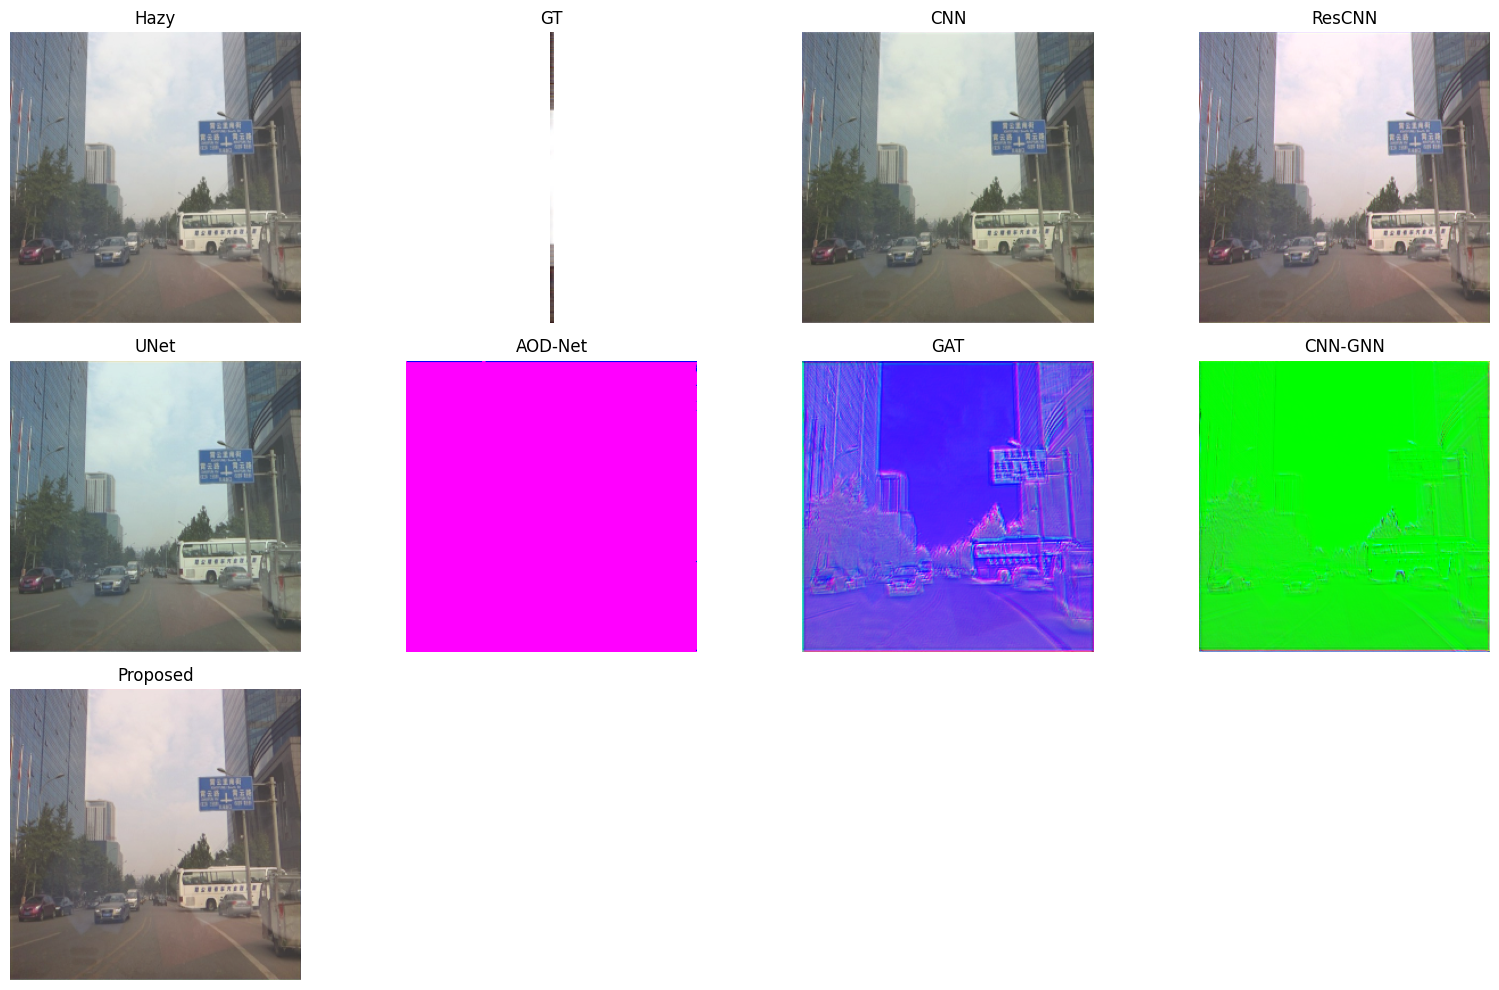

In [51]:

images = {
    "Hazy": hazy,
    "GT": gt
}

images.update(outputs)


n = len(images)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(16, 10))

for i, (name, img) in enumerate(images.items()):
    plt.subplot(rows, cols, i+1)

    img = tensor_to_img(img)

    plt.imshow(img)
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

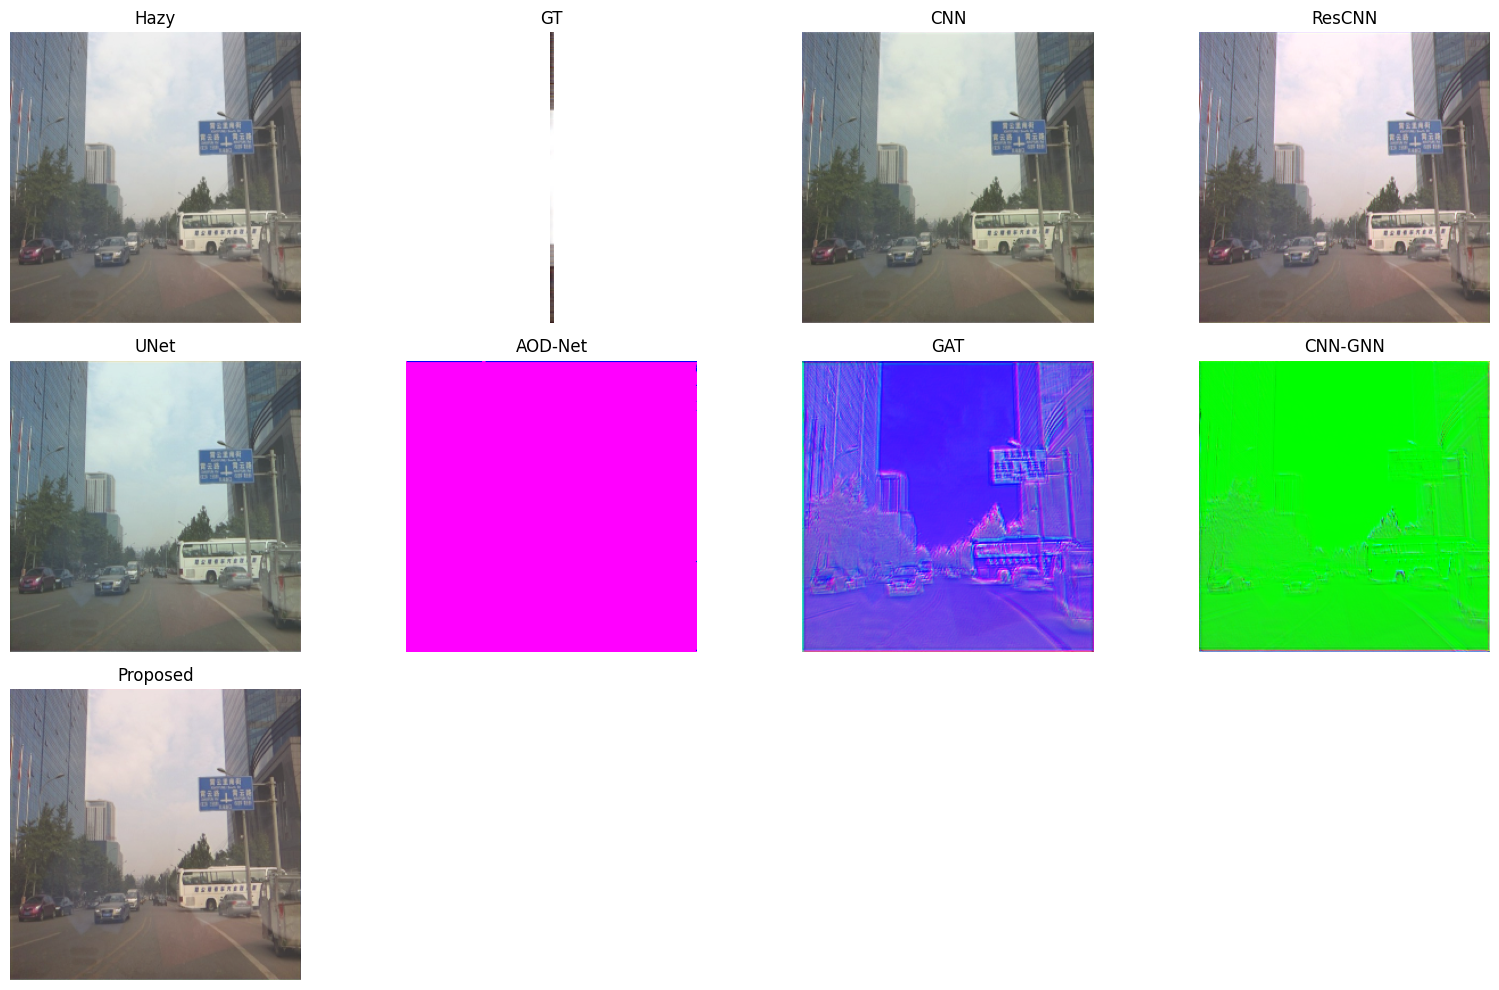

In [52]:
save_path = "./results"
os.makedirs(save_path, exist_ok=True)

plt.figure(figsize=(16, 10))

for i, (name, img) in enumerate(images.items()):
    plt.subplot(rows, cols, i+1)

    img = tensor_to_img(img)

    plt.imshow(img)
    plt.title(name)
    plt.axis('off')

plt.tight_layout()

plt.savefig(os.path.join(save_path, "comparison_grid.png"),
            dpi=300, bbox_inches='tight')

plt.show()

In [55]:
import torch
import piq

def evaluate_model(model, loader):
    model.eval()
    psnr_list = []
    ssim_list = []

    with torch.no_grad():
        for hazy, gt in loader:
            hazy, gt = hazy.to(device), gt.to(device)

            output = model(hazy)

            if isinstance(output, tuple):
                output = output[0]
            output = torch.clamp(output, 0, 1)

            psnr_val = piq.psnr(output, gt, data_range=1.)
            ssim_val = piq.ssim(output, gt, data_range=1.)

            psnr_list.append(psnr_val.item())
            ssim_list.append(ssim_val.item())

    return sum(psnr_list)/len(psnr_list), sum(ssim_list)/len(ssim_list)

In [56]:
results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")

    psnr, ssim = evaluate_model(model, loader)

    results[name] = {
        "PSNR": psnr,
        "SSIM": ssim
    }

    print(f"{name} → PSNR: {psnr:.2f}, SSIM: {ssim:.4f}")


Evaluating CNN...
CNN → PSNR: 15.90, SSIM: 0.7566

Evaluating ResCNN...
ResCNN → PSNR: 12.74, SSIM: 0.7292

Evaluating UNet...
UNet → PSNR: 15.70, SSIM: 0.7510

Evaluating AOD-Net...
AOD-Net → PSNR: 5.90, SSIM: 0.4298

Evaluating GAT...
GAT → PSNR: 11.08, SSIM: 0.4162

Evaluating CNN-GNN...
CNN-GNN → PSNR: 11.09, SSIM: 0.4153

Evaluating Proposed...
Proposed → PSNR: 5.02, SSIM: 0.4287


In [57]:
print("\n===== FINAL RESULTS =====")

for name, res in results.items():
    print(f"{name:10s} | PSNR: {res['PSNR']:.2f} | SSIM: {res['SSIM']:.4f}")


===== FINAL RESULTS =====
CNN        | PSNR: 15.90 | SSIM: 0.7566
ResCNN     | PSNR: 12.74 | SSIM: 0.7292
UNet       | PSNR: 15.70 | SSIM: 0.7510
AOD-Net    | PSNR: 5.90 | SSIM: 0.4298
GAT        | PSNR: 11.08 | SSIM: 0.4162
CNN-GNN    | PSNR: 11.09 | SSIM: 0.4153
Proposed   | PSNR: 5.02 | SSIM: 0.4287


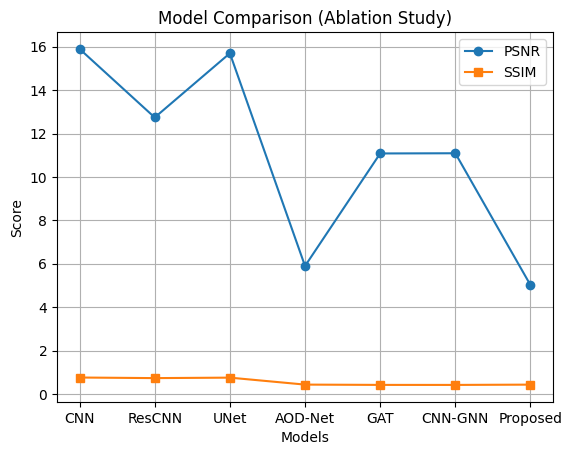

In [58]:
import matplotlib.pyplot as plt

names = list(results.keys())
psnr_vals = [results[n]["PSNR"] for n in names]
ssim_vals = [results[n]["SSIM"] for n in names]

plt.figure()

plt.plot(names, psnr_vals, marker='o', label='PSNR')
plt.plot(names, ssim_vals, marker='s', label='SSIM')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison (Ablation Study)")
plt.legend()
plt.grid()

plt.show()